In [ ]:
## Library Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import shutil
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

## Defining File Paths
train_dir = '/content/drive/MyDrive/train'
test_dir = '/content/drive/MyDrive/test'
flattened_train_dir = '/content/flattened_train'
flattened_test_dir = '/content/flattened_test'

## Function to Flatten Nested Folder Structure
def flatten_dataset(src_dir, dest_dir):
    if not os.path.exists(src_dir):
        raise FileNotFoundError(f"Source directory {src_dir} does not exist!")
    if os.path.exists(dest_dir):
        shutil.rmtree(dest_dir)
    os.makedirs(dest_dir, exist_ok=True)
    for denom in os.listdir(src_dir):
        denom_path = os.path.join(src_dir, denom)
        if os.path.isdir(denom_path):
            for authenticity in os.listdir(denom_path):
                authenticity_path = os.path.join(denom_path, authenticity)
                if os.path.isdir(authenticity_path):
                    for view in os.listdir(authenticity_path):
                        view_path = os.path.join(authenticity_path, view)
                        if os.path.isdir(view_path):
                            target_dir = os.path.join(dest_dir, authenticity)
                            os.makedirs(target_dir, exist_ok=True)
                            for img in os.listdir(view_path):
                                img_path = os.path.join(view_path, img)
                                if os.path.isfile(img_path):
                                    shutil.copy(img_path, os.path.join(target_dir, img))

try:
    flatten_dataset(train_dir, flattened_train_dir)
    flatten_dataset(test_dir, flattened_test_dir)
except Exception as e:
    print(f"Error flattening datasets: {e}")
    raise

## Function to Preprocess and Augment Data
def preprocess_data(directory, target_size=(224, 224), batch_size=32, augmentation=True):
    if augmentation:
        datagen = ImageDataGenerator(
            rescale=1.0 / 255,
            rotation_range=30,
            width_shift_range=0.3,
            height_shift_range=0.3,
            shear_range=0.3,
            zoom_range=0.3,
            horizontal_flip=True,
            brightness_range=[0.8, 1.2],
            fill_mode='nearest'
        )
    else:
        datagen = ImageDataGenerator(rescale=1.0 / 255)
    return datagen.flow_from_directory(
        directory,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True
    )

## Data Preprocessing
train_generator = preprocess_data(flattened_train_dir, augmentation=True)
test_generator = preprocess_data(flattened_test_dir, augmentation=False)

# Check class balance and compute weights
class_counts = Counter(train_generator.classes)
print("Training data class distribution:", class_counts)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights to balance data:", class_weight_dict)

# Debug: Check a batch
images, labels = next(train_generator)
print("Sample batch labels (0=fake, 1=genuine):", labels[:10])

Found 4330 images belonging to 2 classes.
Found 1083 images belonging to 2 classes.
Training data class distribution: Counter({np.int32(1): 2859, np.int32(0): 1471})
Class weights to balance data: {0: np.float64(1.4717878993881712), 1: np.float64(0.7572577824414131)}
Sample batch labels (0=fake, 1=genuine): [0. 1. 1. 1. 1. 1. 1. 0. 0. 0.]


Found 4330 images belonging to 2 classes.
Found 1083 images belonging to 2 classes.
Training data class distribution: Counter({np.int32(1): 2859, np.int32(0): 1471})
Class weights to balance data: {0: np.float64(1.4717878993881712), 1: np.float64(0.7572577824414131)}
Sample batch labels (0=fake, 1=genuine): [1. 1. 1. 0. 1. 0. 1. 1. 0. 1.]
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16: Froze 14 layers, training 5 layers.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
136/136 - 294s - 2s/step - accuracy: 0.8450 - loss: 3.0705 - val_accuracy: 0.4395 - val_loss: 4.1402
Epoch 2/30
136/136 - 216s - 2s/step - accuracy: 0.9376 - loss: 0.7193 - val_accuracy: 0.9095 - val_loss: 0.5984
Epoch 3/30
136/136 - 213s - 2s/step - accuracy: 0.9637 - loss: 0.3208 - val_accuracy: 0.9492 - val_loss: 0.2703
Epoch 4/30
136/136 - 260s - 2s/step - accuracy: 0.9670 - loss: 0.2025 - val_accuracy: 0.7258 - val_loss: 0.7576
Epoch 5/30
136/136 - 213s - 2s/step - accuracy: 0.9704 - loss: 0.1546 - val_accuracy: 0.7248 - val_loss: 0.7680
Epoch 6/30
136/136 - 215s - 2s/step - accuracy: 0.9778 - loss: 0.1121 - val_accuracy: 0.9815 - val_loss: 0.0880
Epoch 7/30
136/136 - 215s - 2s/step - accuracy: 0.9801 - loss: 0.1001 - val_accuracy: 0.9880 - val_loss: 0.0814
Epoch 8/30
136/136 - 205s - 2s/step - accuracy: 0.9739 - loss: 0.1236 - val_accuracy: 0.9898 - val_loss: 0.1022
Epoch 9/30
136/136 - 292s - 2s/step - accuracy: 0.9774 - loss: 0.1122 - val_accuracy: 0.9880 - val_loss:

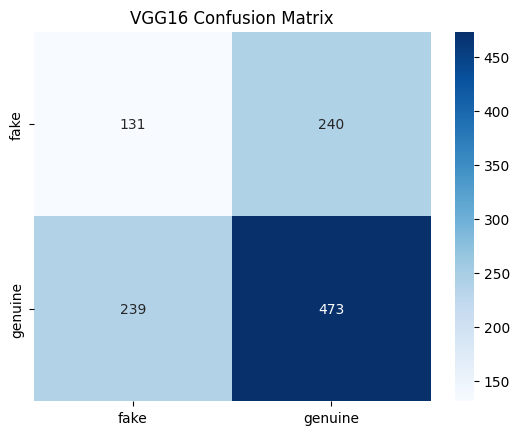

Saved VGG16 as 'VGG16_currency_model.h5'


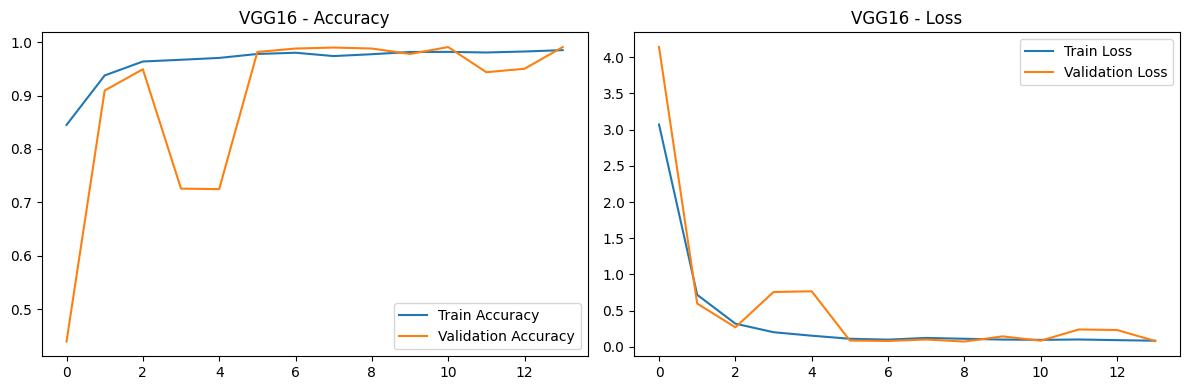

In [ ]:
## Build VGG16 Model
def build_vgg16():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True
    total_layers = len(base_model.layers)
    freeze_until = int(total_layers * 0.75)  # Freeze 75%, train 25%
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    print(f"VGG16: Froze {freeze_until} layers, training {total_layers - freeze_until} layers.")

    model = Sequential([
        base_model,
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

vgg16_model = build_vgg16()

# Train VGG16
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
vgg16_history = vgg16_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=2
)

## Evaluate VGG16
test_loss, test_acc = vgg16_model.evaluate(test_generator, steps=len(test_generator))
print(f"VGG16 Test Accuracy: {test_acc:.3f}")
predictions = vgg16_model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
print("\nVGG16 Classification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=['fake', 'genuine']))
cm = confusion_matrix(test_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fake', 'genuine'], yticklabels=['fake', 'genuine'])
plt.title('VGG16 Confusion Matrix')
plt.show()

# Save VGG16 for production
vgg16_model.save('VGG16_currency_model.h5')
print("Saved VGG16 as 'VGG16_currency_model.h5'")

## Plot VGG16 Training History
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(vgg16_history.history, 'VGG16')

In [ ]:
vgg16_model.save('VGG16_currency_model.h5')
print("Saved VGG16 as 'VGG16_currency_model.h5'")

Saved VGG16 as 'VGG16_currency_model.h5'


In [ ]:
from tensorflow.keras.applications import InceptionV3

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
InceptionV3: Froze 233 layers, training 78 layers.
Epoch 1/30
136/136 - 294s - 2s/step - accuracy: 0.9236 - loss: 4.6523 - val_accuracy: 0.8984 - val_loss: 1.5950
Epoch 2/30
136/136 - 258s - 2s/step - accuracy: 0.9658 - loss: 0.7552 - val_accuracy: 0.9751 - val_loss: 0.3732
Epoch 3/30
136/136 - 272s - 2s/step - accuracy: 0.9718 - loss: 0.3147 - val_accuracy: 0.9511 - val_loss: 0.2664
Epoch 4/30
136/136 - 250s - 2s/step - accuracy: 0.9769 - loss: 0.2245 - val_accuracy: 0.9769 - val_loss: 0.1897
Epoch 5/30
136/136 - 208s - 2s/step - accuracy: 0.9788 - loss: 0.1885 - val_accuracy: 0.9861 - val_loss: 0.1558
Epoch 6/30
136/136 - 285s - 2s/step - accuracy: 0.9866 - loss: 0.1617 - val_accuracy: 0.9889 - val_loss: 0.1650
Epoch 7/30
136/136 - 229s - 2s/step - accuracy: 0.9850 - loss: 0.1496 - val_accuracy: 0.9889 - val_loss: 0.1420
Epoch 8/30
136/136 - 249s - 2s/step - accuracy: 0.9822 - loss: 0.2266 - val_accuracy: 0.9917 - val_loss: 0.1688
Ep

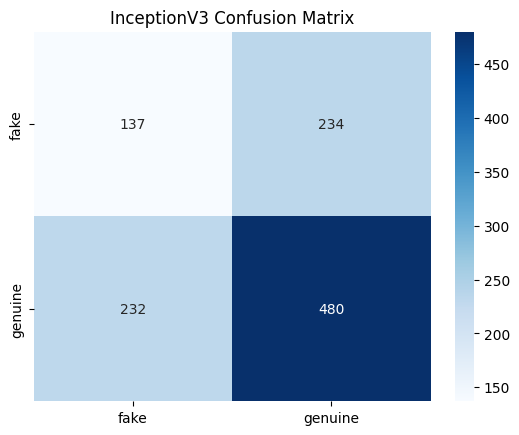

Saved InceptionV3 as 'InceptionV3_currency_model.h5'


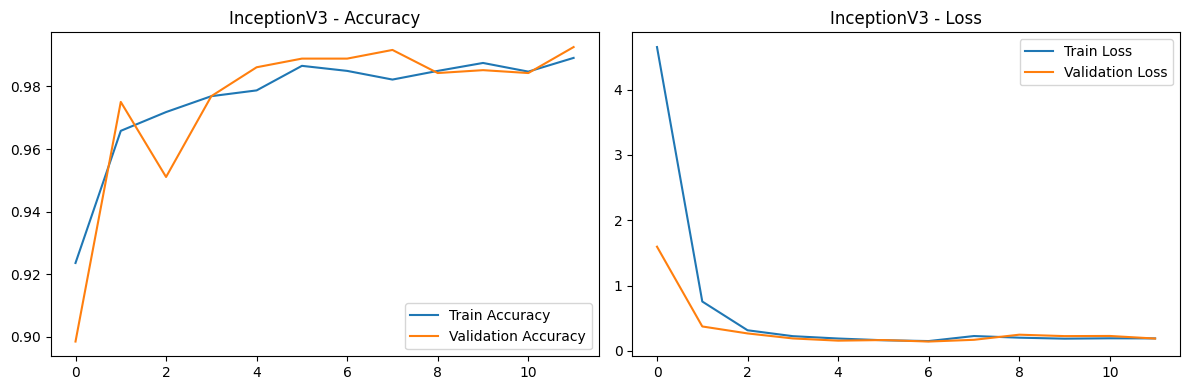

In [ ]:
## Build InceptionV3 Model
def build_inceptionv3():
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True
    total_layers = len(base_model.layers)
    freeze_until = int(total_layers * 0.75)  # Freeze 75%, train 25%
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    print(f"InceptionV3: Froze {freeze_until} layers, training {total_layers - freeze_until} layers.")

    model = Sequential([
        base_model,
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

inceptionv3_model = build_inceptionv3()

# Train InceptionV3
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
inceptionv3_history = inceptionv3_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=2
)

## Evaluate InceptionV3
test_loss, test_acc = inceptionv3_model.evaluate(test_generator, steps=len(test_generator))
print(f"InceptionV3 Test Accuracy: {test_acc:.3f}")
predictions = inceptionv3_model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
print("\nInceptionV3 Classification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=['fake', 'genuine']))
cm = confusion_matrix(test_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fake', 'genuine'], yticklabels=['fake', 'genuine'])
plt.title('InceptionV3 Confusion Matrix')
plt.show()

# Save InceptionV3 for production
inceptionv3_model.save('InceptionV3_currency_model.h5')
print("Saved InceptionV3 as 'InceptionV3_currency_model.h5'")

## Plot InceptionV3 Training History
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(inceptionv3_history.history, 'InceptionV3')

In [ ]:
inceptionv3_model.save('InceptionV3_currency_model.h5')
print("Saved InceptionV3 as 'InceptionV3_currency_model.h5'")

Saved InceptionV3 as 'InceptionV3_currency_model.h5'


In [ ]:
from tensorflow.keras.applications import ResNet50

ResNet50: Froze 87 layers, training 88 layers.
Epoch 1/7
136/136 - 258s - 2s/step - accuracy: 0.5852 - loss: 6.6508 - val_accuracy: 0.3306 - val_loss: 4.8018
Epoch 2/7
136/136 - 204s - 2s/step - accuracy: 0.7051 - loss: 3.7993 - val_accuracy: 0.6353 - val_loss: 3.4455
Epoch 3/7
136/136 - 197s - 1s/step - accuracy: 0.8176 - loss: 2.5686 - val_accuracy: 0.3426 - val_loss: 18.1788
Epoch 4/7
136/136 - 208s - 2s/step - accuracy: 0.8859 - loss: 1.8765 - val_accuracy: 0.5836 - val_loss: 2.3204
Epoch 5/7
136/136 - 196s - 1s/step - accuracy: 0.8986 - loss: 1.4765 - val_accuracy: 0.5808 - val_loss: 1.7818
Epoch 6/7
136/136 - 211s - 2s/step - accuracy: 0.9150 - loss: 1.1701 - val_accuracy: 0.9705 - val_loss: 0.9723
Epoch 7/7
136/136 - 188s - 1s/step - accuracy: 0.9055 - loss: 1.0244 - val_accuracy: 0.3426 - val_loss: 4.0193
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 780ms/step - accuracy: 0.9773 - loss: 0.9654
ResNet50 Test Accuracy: 0.970
34/34 ━━━━━━━━━━━━━━━━━━━━ 35s 883ms/step

ResNet50 Classification Re

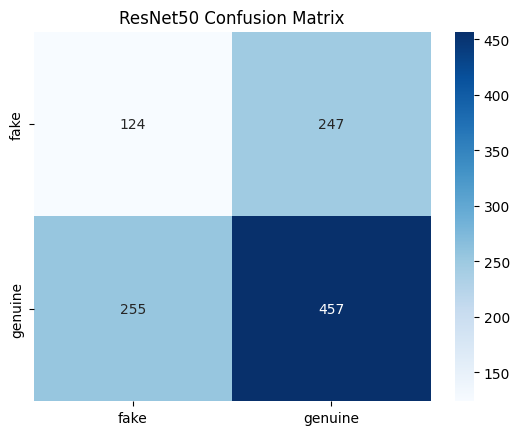

Saved ResNet50 as 'ResNet50_currency_model.h5'


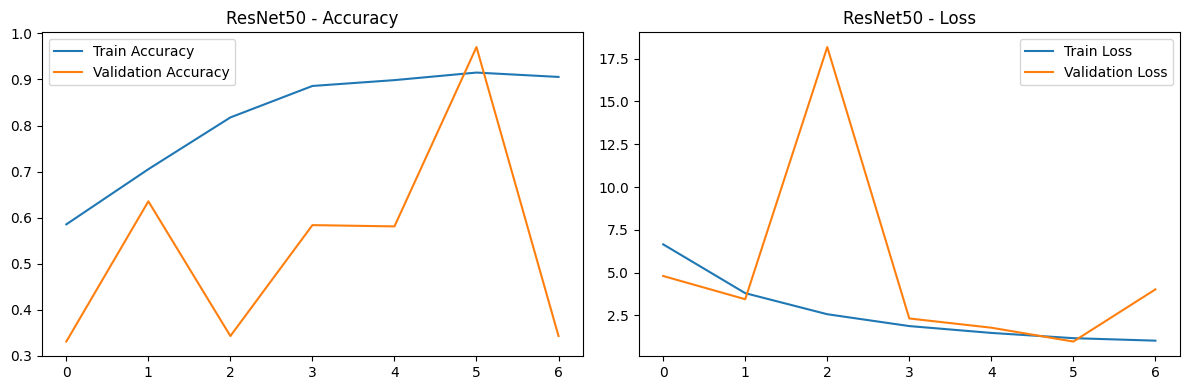

In [ ]:
## Build ResNet50 Model (Enhanced)
def build_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True
    total_layers = len(base_model.layers)
    freeze_until = total_layers // 2  # Unfreeze 50%
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    print(f"ResNet50: Froze {freeze_until} layers, training {total_layers - freeze_until} layers.")

    model = Sequential([
        base_model,
        Dropout(0.3, name='extra_dropout'),
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

resnet50_model = build_resnet50()

# Train ResNet50
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
resnet50_history = resnet50_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=7,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=2
)

## Evaluate ResNet50
test_loss, test_acc = resnet50_model.evaluate(test_generator, steps=len(test_generator))
print(f"ResNet50 Test Accuracy: {test_acc:.3f}")
predictions = resnet50_model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
print("\nResNet50 Classification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=['fake', 'genuine']))
cm = confusion_matrix(test_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fake', 'genuine'], yticklabels=['fake', 'genuine'])
plt.title('ResNet50 Confusion Matrix')
plt.show()

# Save ResNet50 for production
resnet50_model.save('ResNet50_currency_model.h5')
print("Saved ResNet50 as 'ResNet50_currency_model.h5'")

## Plot ResNet50 Training History
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(resnet50_history.history, 'ResNet50')

In [ ]:
from tensorflow.keras.applications import MobileNetV2

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2: Froze 115 layers, training 39 layers.
Epoch 1/30
136/136 - 228s - 2s/step - accuracy: 0.9242 - loss: 4.4459 - val_accuracy: 0.4118 - val_loss: 6.7305
Epoch 2/30
136/136 - 240s - 2s/step - accuracy: 0.9702 - loss: 0.9376 - val_accuracy: 0.3527 - val_loss: 7.9753
Epoch 3/30
136/136 - 213s - 2s/step - accuracy: 0.9813 - loss: 0.3926 - val_accuracy: 0.3453 - val_loss: 11.8127
Epoch 4/30
136/136 - 192s - 1s/step - accuracy: 0.9855 - loss: 0.2979 - val_accuracy: 0.3564 - val_loss: 6.4594
Epoch 5/30
136/136 - 200s - 1s/step - accuracy: 0.9834 - loss: 0.2605 - val_accuracy: 0.8246 - val_loss: 0.7169
Epoch 6/30
136/136 - 201s - 1s/step - accuracy: 0.9875 - loss: 0.2177 - val_accuracy: 0.3666 - val_loss: 7.1347
Epoch 7/30
136/136 - 205s - 2s/step - accuracy: 0.9820 - loss: 0.2236 - val_accuracy: 0.6168 - val_loss: 2.2254
Epoch 8/30
136/136 - 243s - 2s/step - accuracy: 0.9781 - loss: 0.4835 - val_accuracy: 0.4192 - val_loss: 5.3093
Epo

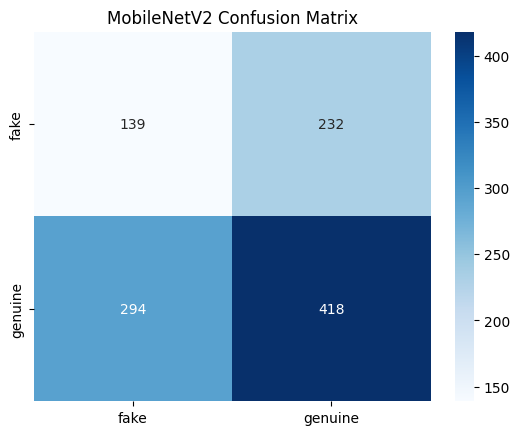

Saved MobileNetV2 as 'MobileNetV2_currency_model.h5'


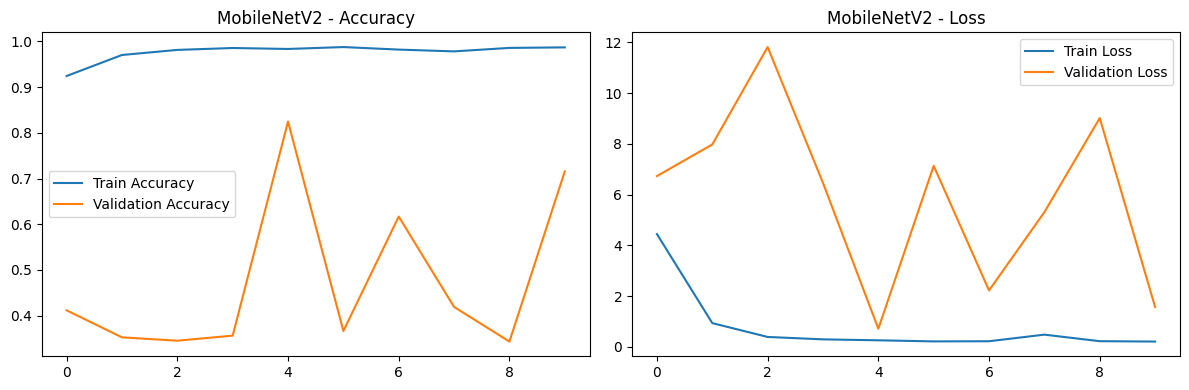

In [ ]:
## Build MobileNetV2 Model
def build_mobilenetv2():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True
    total_layers = len(base_model.layers)
    freeze_until = int(total_layers * 0.75)  # Freeze 75%, train 25%
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    print(f"MobileNetV2: Froze {freeze_until} layers, training {total_layers - freeze_until} layers.")

    model = Sequential([
        base_model,
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

mobilenetv2_model = build_mobilenetv2()

# Train MobileNetV2
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mobilenetv2_history = mobilenetv2_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=2
)

## Evaluate MobileNetV2
test_loss, test_acc = mobilenetv2_model.evaluate(test_generator, steps=len(test_generator))
print(f"MobileNetV2 Test Accuracy: {test_acc:.3f}")
predictions = mobilenetv2_model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
print("\nMobileNetV2 Classification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=['fake', 'genuine']))
cm = confusion_matrix(test_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fake', 'genuine'], yticklabels=['fake', 'genuine'])
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

# Save MobileNetV2 for production
mobilenetv2_model.save('MobileNetV2_currency_model.h5')
print("Saved MobileNetV2 as 'MobileNetV2_currency_model.h5'")

## Plot MobileNetV2 Training History
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(mobilenetv2_history.history, 'MobileNetV2')